# Metadata

**class 1** = World
**class 2** = Sports
**class 3** = Business
**class 4** = Sci/Tech

`pip install -r requirements.txt` before running these notebooks

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [ ]:
from matplotlib.ticker import PercentFormatter

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

In [ ]:
sns.set_theme

<function seaborn.rcmod.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)>

In [ ]:
pip install dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.1 MB/s eta 0:00:00


In [ ]:
from dmba import classificationSummary, gainsChart, liftChart

Colab environment detected.


In [ ]:
from pathlib import Path
import os

def find_repo_root(start=None):
    start = Path(start or os.getcwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing data/raw/")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Repo root:", REPO_ROOT)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

# Description of Objective

- **Goal**: Predict subject matter of article (class) based on title vs description vs title+description of the articles.
- **Predictive Task**: Multinomial classification.
- **Inputs**: Article text.
- **Output**: Predicted class label (4 potential classes).

In [ ]:
train_data = pd.read_csv(TRAIN_PATH, header=0).rename(columns={'Class Index':'class',
                                                   'Title':'title','Description':'description'})

In [ ]:
test_data = pd.read_csv(TEST_PATH, header=0).rename(columns={'Class Index':'class',
                                                   'Title':'title','Description':'description'})

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   class        120000 non-null  int64 
 1   title        120000 non-null  object
 2   description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class        7600 non-null   int64 
 1   title        7600 non-null   object
 2   description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [ ]:
train_data.shape

(120000, 3)

In [ ]:
test_data.shape

(7600, 3)

In [ ]:
train_data['class'].value_counts(normalize=True)

,proportion
class,
3,0.25
4,0.25
2,0.25
1,0.25


In [ ]:
test_data['class'].value_counts(normalize=True)

,proportion
class,
3,0.25
4,0.25
2,0.25
1,0.25


In [ ]:
train_data.duplicated().sum()

np.int64(0)

In [ ]:
test_data.duplicated().sum()

np.int64(0)

# Data Visualization

In [ ]:
class_mapping = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Sci/Tech'
}
train_data = train_data.assign(
    class_name=train_data['class'].map(class_mapping)
)
train_data.head()

,class,title,description,class_name
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business


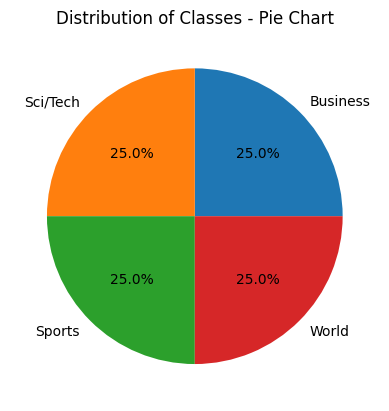

In [ ]:
train_data.class_name.value_counts().plot(
    kind='pie', autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Distribution of Classes - Pie Chart')
plt.show()

# Feature-label separation

In [ ]:
train_title = train_data.title

In [ ]:
train_description = train_data.description

In [ ]:
train_both = train_data.title + " " + train_data.description

In [ ]:
train_response = train_data['class']

In [ ]:
test_title = test_data.title
test_description = test_data.description
test_both = test_data.title + " " + test_data.description

In [ ]:
test_response = test_data['class']

# Naive Bayes Classifier

**Reason for no cross-validation**
 - (almost) no hyperparameters to tune. CV would give limited benefit
 - Plus, with balanced classes across a large dataset, single stratified split returns low variance estimates -> stable accuracy.
 - Naive Bayes serving as a baseline model.

## Title Only

In [ ]:
# train/validation split
X_train_title, X_val_title, y_train_title, y_val_title = train_test_split(
    train_title, train_response, test_size=0.1, stratify=train_response, random_state=1
)

In [ ]:
vectorizer_nb = TfidfVectorizer(
    stop_words='english', # removes common words like 'the','and', and 'is
    max_features=30000, # determines number of columns in feature matrix (top30K features ranked by term frequency across corpus) e.g., regularization parameter
    ngram_range=(1,2) # includes both unigrams and bigrams as features

)

# shape = (n_documents, 30000)

In [ ]:
X_train_title_vec = vectorizer_nb.fit_transform(X_train_title)

Above the following on the training data:

1. Text normalization (e.g., lowercasing and punctuation handling)

2. Tokenization (splits text into tokens/separate words)

3. Vocabulary construction:
 - Builds a dictionary in which each token becomes a column in the matrix (unigrams and bigrams)

4. Term Frequency Computation (counts token occurrences per document)

5. Inverse Document Frequency (IDF)
 - computes IDF(t) = log(N+1/df(t)+1) + 1

6. TF x IDF weighting

7. L2 Normalization (for each document vector) applied to each TF-IDF score per document (score/||x||)
 - ensures model is not biased by document length (e.g., two articles (both same topic) are of different lengths but same words, the longer one would not be seen as "equivalent" to the shorter one because much higher dot product)

8. Returns a sparse document x term matrix (n_documents, 30000)

In [ ]:
X_val_title_vec = vectorizer_nb.transform(X_val_title)

Above applies the same normalized TFIDF matrix to the validation data (doesn't refit anything)
 - Will have same tokens in each column

In [ ]:
preds=[]

for a in [0.1, 0.5, 1.0]:
  nb = MultinomialNB(alpha=a)
  nb.fit(X_train_title_vec, y_train_title)
  preds.append(nb.predict(X_val_title_vec))

In [ ]:
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

In [ ]:
# Laplace Smoothing set to 0.1
classificationSummary(y_val_title, preds[0], class_names=class_names)

Confusion Matrix (Accuracy 0.8689)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2614      137      140      109
  Sports      105     2764       54       77
Business      125       50     2519      306
Sci/Tech      140       92      238     2530


In [ ]:
# Laplace Smoothing set to 0.5
classificationSummary(y_val_title, preds[1], class_names=class_names)

Confusion Matrix (Accuracy 0.8682)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2609      144      145      102
  Sports      104     2773       48       75
Business      124       58     2519      299
Sci/Tech      144       99      240     2517


In [ ]:
# Laplace Smoothing set to 1.0
classificationSummary(y_val_title, preds[2], class_names=class_names)

Confusion Matrix (Accuracy 0.8681)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2610      144      148       98
  Sports      105     2771       50       74
Business      119       58     2525      298
Sci/Tech      145      103      241     2511


## Description Only

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(train_description, train_response,
                 test_size=0.1, stratify=train_response, random_state=1)

In [ ]:
X_train_vec = vectorizer_nb.fit_transform(X_train)

In [ ]:
X_val_vec = vectorizer_nb.transform(X_val)

In [ ]:
alphas = [0.1, 0.5, 1.0]

In [ ]:
preds = []

for a in alphas:
  nb = MultinomialNB(alpha=a)
  nb.fit(X_train_vec, y_train)
  preds.append(nb.predict(X_val_vec))

In [ ]:
# Laplace Smoothing = 0.1
classificationSummary(y_val, preds[0], class_names=class_names)

Confusion Matrix (Accuracy 0.9030)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2663      108      130       99
  Sports       26     2942       17       15
Business       99       24     2562      315
Sci/Tech      120       22      189     2669


In [ ]:
# Laplace Smoothing = 0.5
classificationSummary(y_val, preds[1], class_names=class_names)

Confusion Matrix (Accuracy 0.9032)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2665      109      131       95
  Sports       25     2943       15       17
Business      102       21     2573      304
Sci/Tech      119       29      195     2657


In [ ]:
# Laplace Smoothing = 1.0
classificationSummary(y_val, preds[2], class_names=class_names)

Confusion Matrix (Accuracy 0.9026)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2669      108      134       89
  Sports       25     2942       16       17
Business      104       22     2570      304
Sci/Tech      119       31      200     2650


## Title + Description

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    train_both, train_response, test_size=0.1, stratify=train_response, random_state=1
)

In [ ]:
X_train_vec = vectorizer_nb.fit_transform(X_train)

In [ ]:
X_val_vec = vectorizer_nb.transform(X_val)

In [ ]:
preds = []

for a in alphas:
  nb = MultinomialNB(alpha=a)
  nb.fit(X_train_vec, y_train)
  preds.append(nb.predict(X_val_vec))

In [ ]:
# Laplace Smoothing = 0.1
classificationSummary( y_val, preds[0], class_names=class_names)

Confusion Matrix (Accuracy 0.9126)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2691      108      116       85
  Sports       21     2957       12       10
Business       94       18     2607      281
Sci/Tech      110       16      178     2696


In [ ]:
# Laplace Smoothing = 0.5
classificationSummary(y_val, preds[1], class_names=class_names)

Confusion Matrix (Accuracy 0.9113)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2694      106      119       81
  Sports       23     2954       13       10
Business       98       20     2604      278
Sci/Tech      112       22      182     2684


In [ ]:
# Laplace Smoothing=1.0
classificationSummary(y_val, preds[2], class_names=class_names)

Confusion Matrix (Accuracy 0.9112)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     2698      107      120       75
  Sports       24     2953       13       10
Business       98       21     2605      276
Sci/Tech      114       23      185     2678


# Logistic Regression

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

In [ ]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1,1))),
     ('log', LogisticRegression(max_iter=2000, random_state=1))
])

In [ ]:
log_grid ={
        # L2 (ridge) with lbgfs
  "log__solver": ['lbfgs'], 'log__penalty': ['l2'], 'log__C': [0.001, 0.1, 1, 10]}


In [ ]:
grid = GridSearchCV(pipe, log_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=2)

## Title Only

In [ ]:
grid.fit(train_title, train_response)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid={'log__C': [0.001, 0.1, 1, 10], 'log__penalty': ['l2'],
                         'log__solver': ['lbfgs']},
             scoring='accuracy', verbose=2)

In [ ]:
best_log_params = grid.best_params_

In [ ]:
tfidf_grid = [{
    'log__C': [best_log_params['log__C']],
    'log__penalty': [best_log_params['log__penalty']],
    'log__solver': [best_log_params['log__solver']],
    'tfidf__max_features': [20000, 30000, 40000],
    'tfidf__ngram_range': [(1,1), (1,2)]
}]

In [ ]:
grid2 = GridSearchCV(pipe, tfidf_grid, scoring='accuracy', cv=cv, n_jobs=-1, verbose=0)

In [ ]:
grid2.fit(train_title, train_response)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid=[{'log__C': [1], 'log__penalty': ['l2'],
                          'log__solver': ['lbfgs'],
                          'tfidf__max_features': [20000, 30000, 40000],
                          'tfidf__ngram_range': [(1, 1), (1, 2)]}],
             scoring='accuracy')

In [ ]:
grid2.best_params_

{'log__C': 1,
 'log__penalty': 'l2',
 'log__solver': 'lbfgs',
 'tfidf__max_features': 40000,
 'tfidf__ngram_range': (1, 2)}

In [ ]:
classificationSummary(test_response, grid2.predict(test_title), class_names=class_names)

Confusion Matrix (Accuracy 0.8737)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     1661       93       84       62
  Sports       44     1788       39       29
Business       88       59     1587      166
Sci/Tech       76       70      150     1604


# Description Only

In [ ]:
grid.fit(train_description, train_response)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid={'log__C': [0.001, 0.1, 1, 10], 'log__penalty': ['l2'],
                         'log__solver': ['lbfgs']},
             scoring='accuracy', verbose=2)

In [ ]:
best_log_params = grid.best_params_

In [ ]:
tfidf_grid = [{
    'log__C': [best_log_params['log__C']],
    'log__penalty': [best_log_params['log__penalty']],
    'log__solver': [best_log_params['log__solver']],
    'tfidf__max_features': [20000, 30000, 40000],
    'tfidf__ngram_range': [(1,1), (1,2)]
}]

In [ ]:
grid2.fit(train_description, train_response)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid=[{'log__C': [1], 'log__penalty': ['l2'],
                          'log__solver': ['lbfgs'],
                          'tfidf__max_features': [20000, 30000, 40000],
                          'tfidf__ngram_range': [(1, 1), (1, 2)]}],
             scoring='accuracy')

In [ ]:
classificationSummary(test_response, grid2.predict(test_description), class_names=class_names)

Confusion Matrix (Accuracy 0.9128)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     1717       53       73       57
  Sports       18     1858       16        8
Business       64       21     1658      157
Sci/Tech       47       23      126     1704


# Title and Description

In [ ]:
grid.fit(train_both, train_response)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid={'log__C': [0.001, 0.1, 1, 10], 'log__penalty': ['l2'],
                         'log__solver': ['lbfgs']},
             scoring='accuracy', verbose=2)

In [ ]:
best_log_params = grid.best_params_

In [ ]:
tfidf_grid = [{
    'log__C': [best_log_params['log__C']],
    'log__penalty': [best_log_params['log__penalty']],
    'log__solver': [best_log_params['log__solver']],
    'tfidf__max_features': [20000, 30000, 40000],
    'tfidf__ngram_range': [(1,1), (1,2)]
}]

In [ ]:
grid2.fit(train_both, train_response)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(max_features=20000,
                                                        stop_words='english')),
                                       ('log',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=1))]),
             n_jobs=-1,
             param_grid=[{'log__C': [1], 'log__penalty': ['l2'],
                          'log__solver': ['lbfgs'],
                          'tfidf__max_features': [20000, 30000, 40000],
                          'tfidf__ngram_range': [(1, 1), (1, 2)]}],
             scoring='accuracy')

In [ ]:
classificationSummary(test_response, grid2.predict(test_both), class_names=class_names)

Confusion Matrix (Accuracy 0.9218)

         Prediction
  Actual    World   Sports Business Sci/Tech
   World     1731       54       69       46
  Sports       15     1868       12        5
Business       57       14     1690      139
Sci/Tech       52       18      113     1717


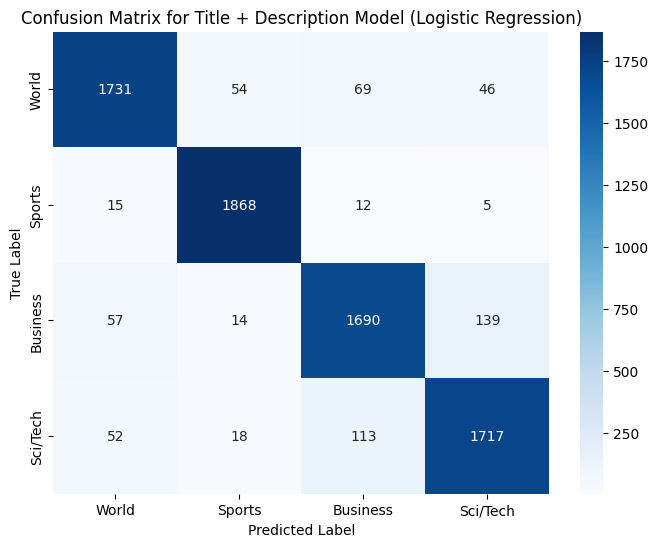

In [ ]:
from sklearn.metrics import confusion_matrix


y_pred_both = grid2.predict(test_both)

cm = confusion_matrix(test_response, y_pred_both)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Title + Description Model (Logistic Regression)')
plt.show()

# Ranking of NGrams

In [ ]:
def get_top_ngrams_tfidf(text_series, ngram_range):
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=ngram_range
    )
    X = vectorizer.fit_transform(text_series)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = X.sum(axis=0).A1 # .A1 converts sparse matrix to 1D array

    # Create a DataFrame for N-grams and their TF-IDF scores
    ngram_df = pd.DataFrame({'N-gram': feature_names, 'TF-IDF Score': tfidf_scores})
    ngram_df = ngram_df.sort_values(by='TF-IDF Score', ascending=False).reset_index(drop=True)
    return ngram_df


In [ ]:
top_unigrams = get_top_ngrams_tfidf(train_both, ngram_range=(1,1))
print("Top 10 Unigrams (Title + Description):")
print(top_unigrams.head(10))

Top 10 Unigrams (Title + Description):
    N-gram  TF-IDF Score
0       39   2801.529216
1      new   1626.880689
2  reuters   1557.613874
3       ap   1530.886727
4     said   1465.234030
5       gt   1147.794439
6       lt   1145.121809
7     quot   1017.212511
8     year    937.221120
9      oil    903.459259


In [ ]:
top_bigrams = get_top_ngrams_tfidf(train_both, ngram_range=(2,2))
print("Top 10 Bigrams (Title + Description):")
print(top_bigrams.head(10))

Top 10 Bigrams (Title + Description):
            N-gram  TF-IDF Score
0            lt gt    628.370661
1            ap ap    535.849009
2         new york    461.303317
3  reuters reuters    343.179499
4            gt lt    324.032886
5       oil prices    264.656245
6    united states    228.351211
7   prime minister    222.433921
8     york reuters    197.087226
9          afp afp    176.652894


In [ ]:
top_trigrams = get_top_ngrams_tfidf(train_both, ngram_range=(3,3))
print("Top 10 Trigrams (Title + Description):")
print(top_trigrams.head(10))

Top 10 Trigrams (Title + Description):
                    N-gram  TF-IDF Score
0                 lt gt lt    263.457690
1                 gt lt gt    261.888249
2         new york reuters    183.651501
3             lt href http    156.333853
4            href http www    154.492813
5  target stocks quickinfo    140.462963
6    reuters com fullquote    140.462963
7       com fullquote aspx    140.462963
8   quickinfo fullquote gt    140.462963
9     investor reuters com    140.462963


In [ ]:
top_unigrams_test = get_top_ngrams_tfidf(test_both, ngram_range=(1,1))
top_bigrams_test = get_top_ngrams_tfidf(test_both, ngram_range=(2,2))
top_trigrams_test = get_top_ngrams_tfidf(test_both, ngram_range=(3,3))

print("Top 10 Test Unigrams:")
print(top_unigrams_test.head(10))
print("\nTop 10 Test Bigrams:")
print(top_bigrams_test.head(10))
print("\nTop 10 Test Trigrams:")
print(top_trigrams_test.head(10))

Top 10 Test Unigrams:
    N-gram  TF-IDF Score
0       39    182.262207
1      new    106.399960
2       ap    101.327219
3     said     98.017118
4  reuters     96.814807
5       gt     69.860112
6       lt     69.439486
7     quot     65.121397
8     year     61.212607
9    world     55.610051

Top 10 Test Bigrams:
            N-gram  TF-IDF Score
0            lt gt     43.753067
1            ap ap     41.867380
2         new york     33.784294
3  reuters reuters     24.331744
4            gt lt     23.302385
5    united states     17.392092
6       oil prices     17.184948
7          afp afp     16.243703
8   prime minister     15.407281
9     york reuters     14.636011

Top 10 Test Trigrams:
                   N-gram  TF-IDF Score
0                lt gt lt     19.922042
1                gt lt gt     19.769494
2        new york reuters     14.298180
3            lt href http     10.316974
4           href http www     10.073825
5  quote profile research      9.269184
6    investor r

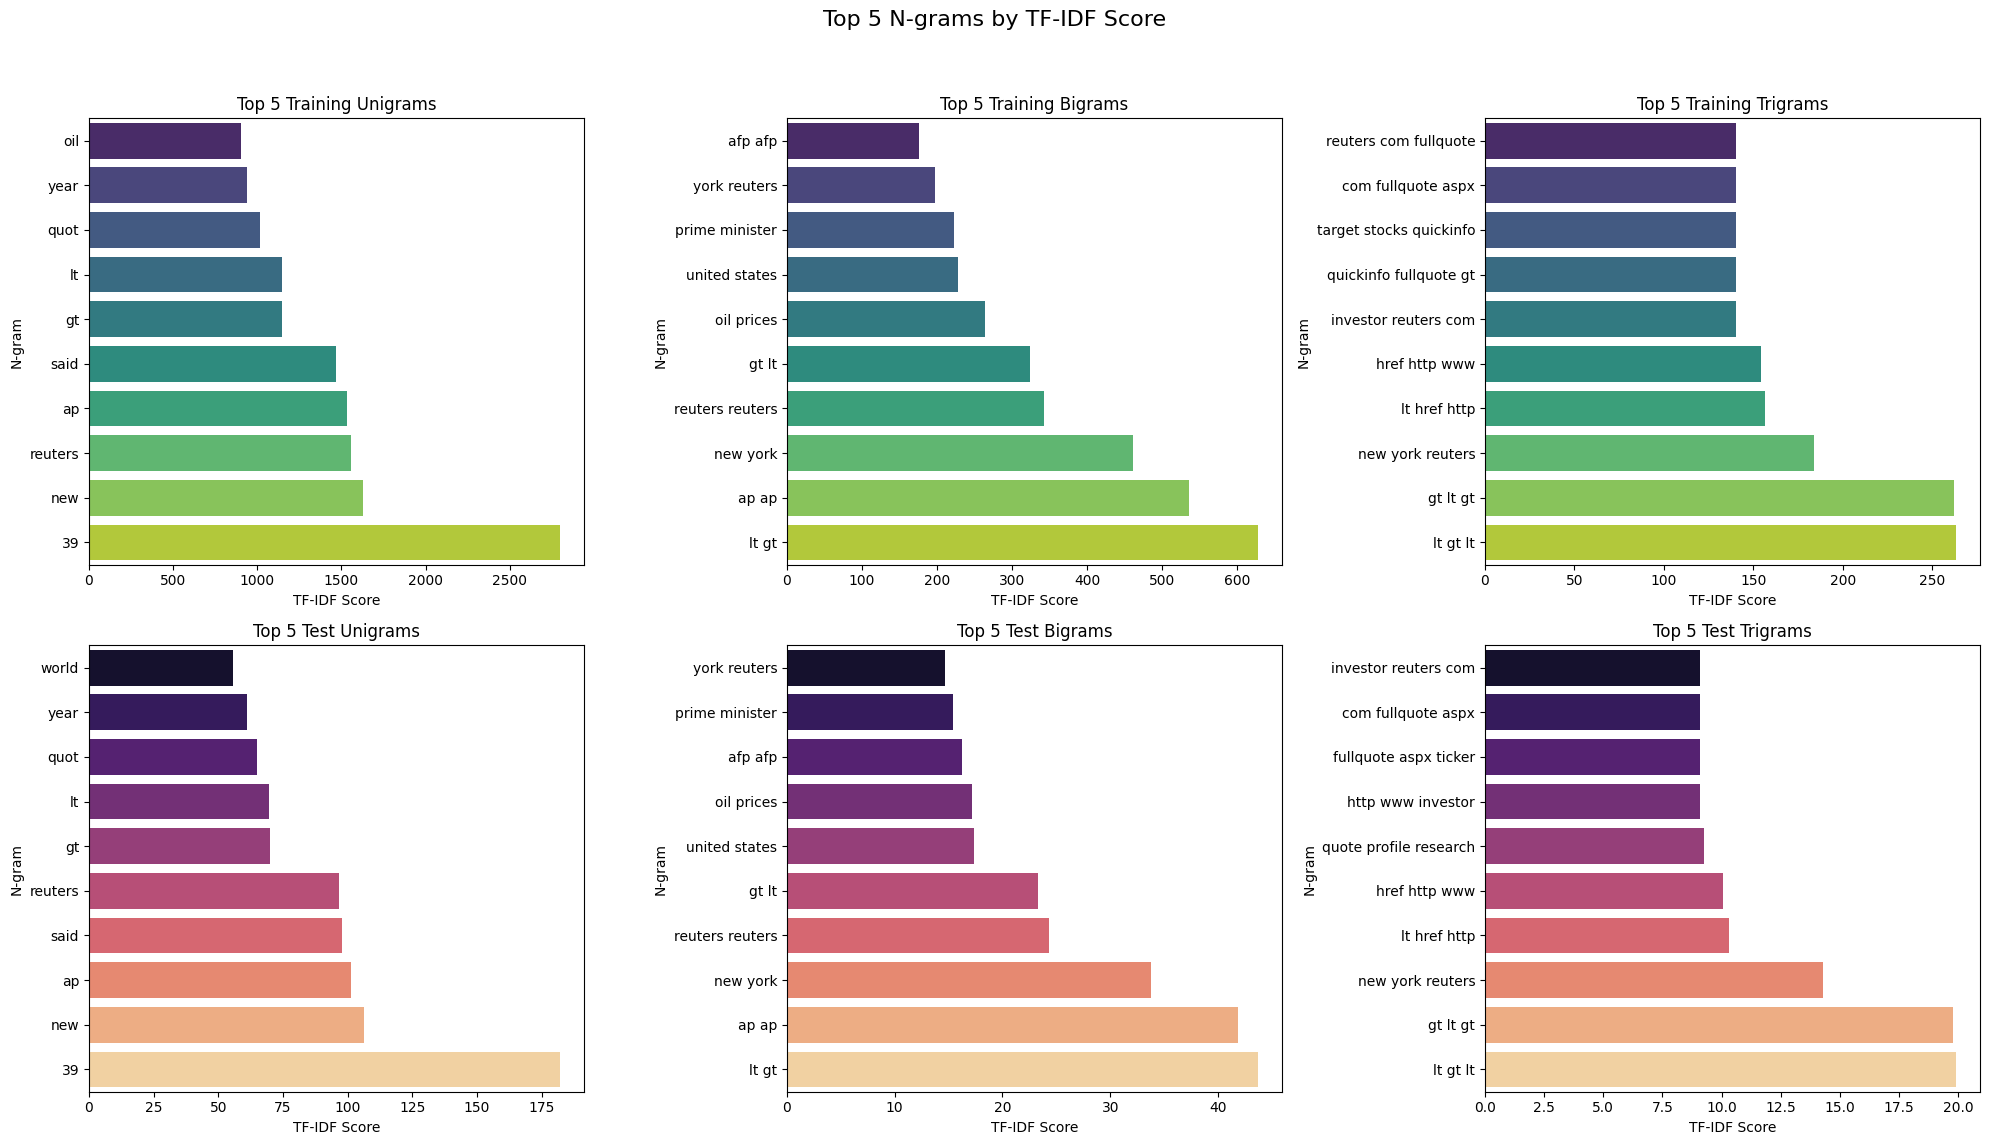

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Top 5 N-grams by TF-IDF Score', fontsize=16)

# Training Data
# Top 10 Training Unigrams
plot_data_unigram_train = top_unigrams.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[0, 0], x='TF-IDF Score', y='N-gram', data=plot_data_unigram_train, palette='viridis', hue='N-gram', legend=False)
axes[0, 0].set_title('Top 5 Training Unigrams')
axes[0, 0].set_xlabel('TF-IDF Score')
axes[0, 0].set_ylabel('N-gram')

# Top 10 Training Bigrams
plot_data_bigram_train = top_bigrams.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[0, 1], x='TF-IDF Score', y='N-gram', data=plot_data_bigram_train, palette='viridis', hue='N-gram', legend=False)
axes[0, 1].set_title('Top 5 Training Bigrams')
axes[0, 1].set_xlabel('TF-IDF Score')
axes[0, 1].set_ylabel('N-gram')

# Top 10 Training Trigrams
plot_data_trigram_train = top_trigrams.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[0, 2], x='TF-IDF Score', y='N-gram', data=plot_data_trigram_train, palette='viridis', hue='N-gram', legend=False)
axes[0, 2].set_title('Top 5 Training Trigrams')
axes[0, 2].set_xlabel('TF-IDF Score')
axes[0, 2].set_ylabel('N-gram')

# Test Data
# Top 10 Test Unigrams
plot_data_unigram_test = top_unigrams_test.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[1, 0], x='TF-IDF Score', y='N-gram', data=plot_data_unigram_test, palette='magma', hue='N-gram', legend=False)
axes[1, 0].set_title('Top 5 Test Unigrams')
axes[1, 0].set_xlabel('TF-IDF Score')
axes[1, 0].set_ylabel('N-gram')

# Top 10 Test Bigrams
plot_data_bigram_test = top_bigrams_test.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[1, 1], x='TF-IDF Score', y='N-gram', data=plot_data_bigram_test, palette='magma', hue='N-gram', legend=False)
axes[1, 1].set_title('Top 5 Test Bigrams')
axes[1, 1].set_xlabel('TF-IDF Score')
axes[1, 1].set_ylabel('N-gram')

# Top 10 Test Trigrams
plot_data_trigram_test = top_trigrams_test.head(10).sort_values(by='TF-IDF Score', ascending=True)
sns.barplot(ax=axes[1, 2], x='TF-IDF Score', y='N-gram', data=plot_data_trigram_test, palette='magma', hue='N-gram', legend=False)
axes[1, 2].set_title('Top 5 Test Trigrams')
axes[1, 2].set_xlabel('TF-IDF Score')
axes[1, 2].set_ylabel('N-gram')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()